**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of multiple fluorophores](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [Figure](#toc1_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of multiple fluorophores](#toc0_)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

reading_from = r"C:\Users\vie43sq\data_vincent\python_output\Additional\different_fluorophore_setups"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Reading data](#toc0_)

In [ ]:
identifiers = ["_4d5nm", "_8and4d5nm", "_8nm"]
fingerprints_all = []
no_norm_all = []
for i, id in enumerate(identifiers):
    fingerprints_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    for file in Path(reading_from).iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_all[i] += pd.read_parquet(file).sum(axis=1)
    fingerprint = fingerprints_all[i].cumsum() / fingerprints_all[i].sum()
    no_norm = fingerprints_all[i].cumsum()
    fingerprints_all[i] = fingerprint
    no_norm_all.append(no_norm)

### <a id='toc1_1_1_'></a>[Figure](#toc0_)

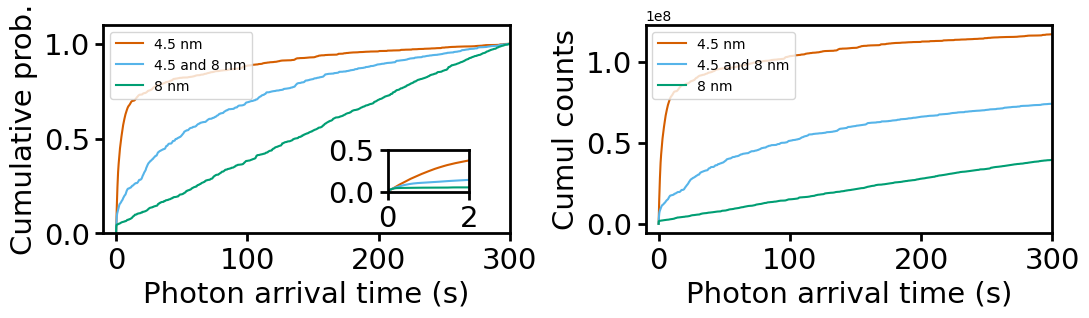

In [39]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax,
    labels,
    data,
    ylim,
    ylabel,
    xlim2,
    ylim2,
    inset,
    inset_x_ticks,
    colors=colors,
):
    description = dict(
        ylabel=ylabel,
        xlabel="Photon arrival time (s)",
        xlim=[-10, 300],
        ylim=ylim,
        legend=True,
        legendargs={"loc": "upper left"},
    )
    for fingerprint, label, color in zip(data, labels, colors):
        fi.universal_figure(
            data=[fingerprint.index, fingerprint],
            label=label,
            color=color,
            marker=None,
            linestyle="-",
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        **description,
    )
    if inset:
        inset = ax.inset_axes([0.7, 0.2, 0.2, 0.2], xlim=xlim2, ylim=ylim2)
        for fingerprint, label, color in zip(data, labels, colors):
            fi.universal_figure(
                data=[fingerprint.index, fingerprint],
                axes=inset,
                label=label,
                color=color,
                linestyle="-",
            )
        inset.set_ylabel("")
        inset.set_xlabel("")
        inset.set_xticks(inset_x_ticks)


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(11, 8.5))


labels1 = ["4.5 nm", "4.5 and 8 nm", "8 nm"]
legendtitle1 = "Distance"
ax1 = fig.add_subplot(gs[0, 0:2])
plot_figure3(
    ax1,
    labels1,
    fingerprints_all,
    [0, 1.1],
    "Cumulative prob.",
    (0, 2),
    [0, 0.5],
    True,
    [0, 2],
)

ax2 = fig.add_subplot(gs[0, 2:])
plot_figure3(
    ax2,
    labels1,
    no_norm_all,
    None,
    "Cumul counts",
    (0, 2),
    None,
    False,
    [0, 2],
)
fig.tight_layout()